---
## 0. Cài đặt môi trường & Load dữ liệu

In [1]:
import os
import pickle
import time
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression as SklearnLR  # chỉ để kiểm chứng
from sklearn.datasets import make_classification

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
print('Đã tải xong tất cả thư viện cần thiết.')

Đã tải xong tất cả thư viện cần thiết.


In [2]:
# Thiết lập đường dẫn và đọc file pickle đã xử lý
_notebook_dir  = os.path.abspath('')
BASE_PATH      = os.path.abspath(os.path.join(_notebook_dir, '..', '..'))
PROC_DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
FIG_PATH       = os.path.join(BASE_PATH, 'report', 'figures', 'lr')
os.makedirs(FIG_PATH, exist_ok=True)

PKL_PATH  = os.path.join(PROC_DATA_PATH, 'processed_data.pkl')

with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train'].values.astype(np.float64)
y_train = data['y_train'].values.astype(int)
X_val   = data['X_val'].values.astype(np.float64)
y_val   = data['y_val'].values.astype(int)
X_test  = data['X_test'].values.astype(np.float64)
y_test  = data['y_test'].values.astype(int)
CLASS_WEIGHTS = data['class_weights'] # {0: w0, 1: w1}


print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print(f'Số đặc trưng: {X_train.shape[1]}')
print(f'Class weights: {CLASS_WEIGHTS}')

Train : (90916, 24)
Val   : (12988, 24)
Test  : (25976, 24)
Số đặc trưng: 24
Class weights: {0: 0.8823540829596848, 1: 1.153844201335127}


# **Part 01: Logistic Regression**
1. Cơ sở lý thuyết + công thức tất cả các thuật toán
2. Cài đặt từ đầu: Gradient Descent & Newton-Raphson / IRLS
3. So sánh tốc độ hội tụ (loss vs epoch, loss vs wall-clock time)
4. Logistic Regression đa lớp: OvR, OvO, Softmax trực tiếp
5. Đánh giá đầy đủ: CV, McNemar test, ROC/PR curve, Calibration

> Toàn bộ phần cài đặt thuật toán em dùng `numpy` thuần, không dùng `sklearn` cho phần học. `sklearn` chỉ dùng để kiểm chứng kết quả.

---
## 1. Lý thuyết đầy đủ

### 1.1 Binary Logistic Regression

**Mô hình:** dự đoán $p = P(y=1|\mathbf{x})$ qua hàm sigmoid:
$$p = \sigma(z) = \frac{1}{1+e^{-z}}, \quad z = \mathbf{w}^\top\mathbf{x}$$

**Hàm mất mát – Binary Cross-Entropy (negative log-likelihood):**
$$J(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^N \Big[y_i\log p_i + (1-y_i)\log(1-p_i)\Big]$$

---
**Chứng minh Gradient:**

Lấy đạo hàm $\partial J / \partial w_j$:
$$\frac{\partial J}{\partial w_j} = -\frac{1}{N}\sum_i\left[\frac{y_i}{p_i}\frac{\partial p_i}{\partial w_j} - \frac{1-y_i}{1-p_i}\frac{\partial p_i}{\partial w_j}\right]$$

Vì $\frac{\partial p_i}{\partial w_j} = p_i(1-p_i)x_{ij}$ (đạo hàm của sigmoid), thay vào:
$$= -\frac{1}{N}\sum_i (y_i - p_i)x_{ij}$$

Dạng ma trận:
$$\boxed{\nabla J(\mathbf{w}) = \frac{1}{N}\mathbf{X}^\top(\mathbf{p} - \mathbf{y})}$$

---
**Chứng minh Hessian:**

Lấy đạo hàm bậc 2 của $J$:
$$H_{jk} = \frac{\partial^2 J}{\partial w_j \partial w_k} = \frac{1}{N}\sum_i p_i(1-p_i)\,x_{ij}x_{ik}$$

Đặt $\mathbf{R} = \text{diag}(r_i)$ với $r_i = p_i(1-p_i)$, dạng ma trận:
$$\boxed{\mathbf{H} = \frac{1}{N}\mathbf{X}^\top\mathbf{R}\mathbf{X}}$$

$\mathbf{H}$ là ma trận nửa xác định dương (PSD) → $J$ là hàm **lồi** → bài toán có nghiệm tối ưu toàn cục.

---
### 1.2 Hai thuật toán tối ưu

**Gradient Descent (bậc 1):**
$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta\underbrace{\frac{1}{N}\mathbf{X}^\top(\mathbf{p}-\mathbf{y})}_{\text{gradient}}$$

**Newton-Raphson / IRLS (bậc 2):**
$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \mathbf{H}^{-1}\nabla J = \mathbf{w}^{(t)} - \underbrace{(\mathbf{X}^\top\mathbf{R}\mathbf{X})^{-1}}_{\text{dùng solve()}}\mathbf{X}^\top(\mathbf{p}-\mathbf{y})$$

| | GD | Newton-Raphson |
|---|---|---|
| Thông tin | Bậc 1 | Bậc 2 (Hessian) |
| Chi phí/bước | $O(NM)$ | $O(NM^2+M^3)$ |
| Số bước hội tụ | $O(1/\varepsilon)$ | $O(\log 1/\varepsilon)$ |
| Nhạy lr | Có | Không |
| Vì sao LR không có nghiệm đóng? | sigmoid phi tuyến → không giải analytic được |

---
### 1.3 Multiclass – Softmax & Jacobian

$$p_k = \frac{e^{a_k}}{\sum_j e^{a_j}}, \quad a_k = \mathbf{w}_k^\top\mathbf{x}$$

**Chứng minh Jacobian** $\partial p_i/\partial a_j$:

- $i=j$: $\quad\dfrac{\partial p_i}{\partial a_i} = \dfrac{e^{a_i}\sum_k e^{a_k} - e^{a_i}\cdot e^{a_i}}{(\sum_k e^{a_k})^2} = p_i(1-p_i)$
- $i\neq j$: $\quad\dfrac{\partial p_i}{\partial a_j} = \dfrac{-e^{a_i}\cdot e^{a_j}}{(\sum_k e^{a_k})^2} = -p_ip_j$

**Dạng ma trận:** $\mathbf{J} = \text{diag}(\mathbf{p}) - \mathbf{p}\mathbf{p}^\top$

$$\frac{\partial L}{\partial a_j} = \sum_k\frac{-t_k}{p_k}\cdot p_k(\delta_{kj}-p_j) = p_j - t_j$$
$$\Rightarrow \boxed{\nabla_{\mathbf{W}} L = \frac{1}{N}\mathbf{X}^\top(\mathbf{Y}-\mathbf{T})}$$
Gradient chỉ là **residual** $\mathbf{Y}-\mathbf{T}$ — giống hệt linear regression!

**Hessian multiclass** có dạng:
$$H_{j,k} = \frac{1}{N}\sum_i p_{ij}(\delta_{jk}-p_{ik})\mathbf{x}_i\mathbf{x}_i^\top$$

## 1. Các hàm hỗ trợ

In [3]:
# Hàm hỗ trợ cho Logistic Regression

def add_intercept(X):
    """Thêm cột bias (toàn số 1) vào đầu ma trận X."""
    return np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)


def sigmoid(z):
    """
    σ(z) = 1 / (1 + e^{-z})
    Dùng np.clip để tránh overflow khi z rất lớn hoặc rất nhỏ.
    """
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))


def softmax(Z):
    """
    Softmax(z)_i = e^{z_i} / Σ_j e^{z_j}  –  Z có shape (N, K)
    Trừ max trước khi exp để tránh overflow (numerical stability).
    """
    Z = Z - Z.max(axis=1, keepdims=True)  # numerical stability
    exp_Z = np.exp(Z)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)


def binary_cross_entropy(y, p, sw=None):
    """
    J = -1/N Σ [y*log(p) + (1-y)*log(1-p)]
    sw: sample weight (để xử lý class imbalance)
    """
    eps = 1e-15
    p   = np.clip(p, eps, 1 - eps)
    bce = y * np.log(p) + (1 - y) * np.log(1 - p)
    if sw is not None:
        bce *= sw
    return -np.mean(bce)


def categorical_cross_entropy(T, P):
    """
    L = -1/N Σ_i Σ_k T_{ik} log(P_{ik})
    T: one-hot (N, K),  P: softmax output (N, K)
    """
    eps = 1e-15
    return -np.mean(np.sum(T * np.log(np.clip(P, eps, 1)), axis=1))


def one_hot(y, K):
    """Chuyển nhãn nguyên → one-hot encoding. Shape: (N, K)"""
    T = np.zeros((len(y), K))
    T[np.arange(len(y)), y] = 1.0
    return T


def sample_weight(y, cw):
    """Tạo vector trọng số mẫu từ class_weight dict {0: w0, 1: w1}."""
    if cw is None:
        return np.ones(len(y))
    return np.where(y == 1, cw[1], cw[0])


def lr_cosine(lr0, epoch, total):
    """Cosine annealing – logistic regression giảm dần mượt mà từ lr0 về 0."""
    return lr0 * 0.5 * (1 + np.cos(np.pi * epoch / total))

def lr_step(lr0, epoch, step=50, decay=0.5):
    """Step decay – logistic regression nhân thêm hệ số decay sau mỗi `step` epoch."""
    return lr0 * (decay ** (epoch // step))


print('Định nghĩa các hàm hỗ trợ xong.')

Định nghĩa các hàm hỗ trợ xong.


---
## 2. Logistic Regression nhị phân – Gradient Descent & Newton-Raphson

In [4]:
# Cài đặthàm `fit_logistic_regression` duy nhất hỗ trợ cả hai chế độ để tiện so sánh.
def fit_logistic_regression(
    X_tr, y_tr,
    X_val=None, y_val=None,
    method='gd',
    lr=0.1,
    epochs=200,
    batch_size=512,    # chỉ dùng cho GD (mini-batch)
    lam=0.0,           # hệ số L2 regularization
    lr_sched='cosine', # 'cosine' | 'step' | 'constant'
    cw=None,           # class_weight dict
    tol=1e-7,
    seed=42,
    verbose=False,
):
    """
    Logistic Regression nhị phân.

    Returns:
        w            – trọng số tối ưu (D+1,)
        train_losses – list BCE loss theo epoch
        val_losses   – list BCE loss trên val theo epoch
        wall_times   – list wall-clock time tích lũy (giây)
    """
    rng = np.random.default_rng(seed)

    # Thêm cột bias
    Xb = add_intercept(X_tr)          # (N, D+1)
    Xv = add_intercept(X_val) if X_val is not None else None
    N, M = Xb.shape

    # Trọng số mẫu (class imbalance)
    sw = sample_weight(y_tr, cw)      # (N,)

    # Khởi tạo w = 0  (cũng có thể init nhỏ ngẫu nhiên)
    w = np.zeros(M)

    train_losses, val_losses, wall_times = [], [], []
    t0 = time.perf_counter()
    prev_loss = np.inf

    for ep in range(epochs):

        # GRADIENT DESCENT (mini-batch)
        if method == 'gd':
            # Chọn learning rate theo schedule
            if lr_sched == 'cosine':
                lr_t = lr_cosine(lr, ep, epochs)
            elif lr_sched == 'step':
                lr_t = lr_step(lr, ep)
            else:
                lr_t = lr

            # Shuffle rồi chia mini-batch
            idx = rng.permutation(N)
            Xs, ys, sws = Xb[idx], y_tr[idx], sw[idx]

            for s in range(0, N, batch_size):
                Xb_ = Xs[s:s+batch_size]
                y_  = ys[s:s+batch_size]
                sw_ = sws[s:s+batch_size]
                nb  = len(y_)

                p_  = sigmoid(Xb_ @ w)

                # grad = (1/B) X^T (p - y)  [có sample weight]
                grad = Xb_.T @ (sw_ * (p_ - y_)) / nb

                # L2 reg – không phạt bias (w[0])
                if lam > 0:
                    r = lam * w.copy(); r[0] = 0
                    grad += r

                w -= lr_t * grad

        # NEWTON-RAPHSON / IRLS
        elif method == 'newton':
            p = sigmoid(Xb @ w)            # (N,)

            # Gradient: (1/N) X^T (p - y)
            grad = Xb.T @ (sw * (p - y_tr)) / N
            if lam > 0:
                r = lam * w.copy(); r[0] = 0
                grad += r

            # Hessian: H = (1/N) X^T R X
            # R = diag(p_i*(1-p_i))  – dùng broadcasting, không tạo ma trận NxN
            R = sw * p * (1 - p)           # (N,) – đường chéo của R
            H = (Xb.T * R) @ Xb / N       # (M, M)
            if lam > 0:
                rd = lam * np.ones(M); rd[0] = 0
                H += np.diag(rd)

            # Cập nhật Newton: w ← w - H^{-1} grad
            # Dùng solve() thay vì tính nghịch đảo tường minh (nhanh hơn, ổn định hơn)
            try:
                delta = np.linalg.solve(H, grad)
            except np.linalg.LinAlgError:
                delta = np.linalg.pinv(H) @ grad  # fallback nếu H suy biến
            w -= delta

            # Newton thường hội tụ rất nhanh nên kiểm tra ||delta|| < tol để dừng sớm
            if np.linalg.norm(delta) < tol:
                if verbose: print(f'  [Newton] Hội tụ tại epoch {ep+1}')
                # Ghi log bước cuối rồi break
                train_losses.append(binary_cross_entropy(y_tr, sigmoid(Xb@w), sw))
                wall_times.append(time.perf_counter() - t0)
                if Xv is not None:
                    val_losses.append(binary_cross_entropy(y_val, sigmoid(Xv@w)))
                break

        # Ghi log cuối mỗi epoch
        tr_loss = binary_cross_entropy(y_tr, sigmoid(Xb@w), sw)
        train_losses.append(tr_loss)
        wall_times.append(time.perf_counter() - t0)
        if Xv is not None:
            val_losses.append(binary_cross_entropy(y_val, sigmoid(Xv@w)))

        # Dừng sớm cho Gradient Descent
        if method == 'gd' and abs(prev_loss - tr_loss) < tol:
            if verbose: print(f'  [Gradient Descent] Hội tụ sớm tại epoch {ep+1}')
            break
        prev_loss = tr_loss

    return w, train_losses, val_losses, wall_times


print('Hàm fit_logistic_regression đã sẵn sàng.')

Hàm fit_logistic_regression đã sẵn sàng.


---
## 3.1 Huấn luyện Gradient Descent

In [5]:
# Gradient Descent (không điều chỉnh)
print('Gradient Descent (không regularization)')
w_gd, loss_gd_tr, loss_gd_val, time_gd = fit_logistic_regression(
    X_train, y_train, X_val, y_val,
    method='gd', lr=0.1, epochs=200, batch_size=512,
    lam=0.0, lr_sched='cosine', cw=CLASS_WEIGHTS,
    seed=SEED, verbose=True
)
acc = accuracy_score(y_val, (sigmoid(add_intercept(X_val) @ w_gd) >= 0.5).astype(int))
print(f'Epochs: {len(loss_gd_tr)} | Val Loss: {loss_gd_val[-1]:.4f} | Val Acc: {acc:.4f}')

# Gradient Descent – L2 regularization
print('\nGradient Descent – L2 regularization (λ=0.01)')
w_gd_l2, loss_gd_l2_tr, loss_gd_l2_val, time_gd_l2 = fit_logistic_regression(
    X_train, y_train, X_val, y_val,
    method='gd', lr=0.1, epochs=200, batch_size=512,
    lam=0.01, lr_sched='cosine', cw=CLASS_WEIGHTS,
    seed=SEED, verbose=True
)
acc2 = accuracy_score(y_val, (sigmoid(add_intercept(X_val) @ w_gd_l2) >= 0.5).astype(int))
print(f'Epochs: {len(loss_gd_l2_tr)} | Val Loss: {loss_gd_l2_val[-1]:.4f} | Val Acc: {acc2:.4f}')

Gradient Descent (không regularization)
  [Gradient Descent] Hội tụ sớm tại epoch 132
Epochs: 132 | Val Loss: 0.3350 | Val Acc: 0.8692

Gradient Descent – L2 regularization (λ=0.01)
  [Gradient Descent] Hội tụ sớm tại epoch 136
Epochs: 136 | Val Loss: 0.3488 | Val Acc: 0.8626


## 3.2 Huấn luyện Newton-Raphson / IRLS

In [6]:
print('Huấn luyện Newton-Raphson / IRLS')
w_nt, loss_nt_tr, loss_nt_val, time_nt = fit_logistic_regression(
    X_train, y_train, X_val, y_val,
    method='newton', epochs=50,
    lam=1e-3, cw=CLASS_WEIGHTS,
    seed=SEED, verbose=True
)
acc3 = accuracy_score(y_val, (sigmoid(add_intercept(X_val) @ w_nt) >= 0.5).astype(int))
print(f'Iterations: {len(loss_nt_tr)} | Val Loss: {loss_nt_val[-1]:.4f} | Val Acc: {acc3:.4f}')

Huấn luyện Newton-Raphson / IRLS
  [Newton] Hội tụ tại epoch 7
Iterations: 7 | Val Loss: 0.3356 | Val Acc: 0.8692


## 3.3 So sánh tốc độ hội tụ: Gradient Descent vs Newton-Raphson

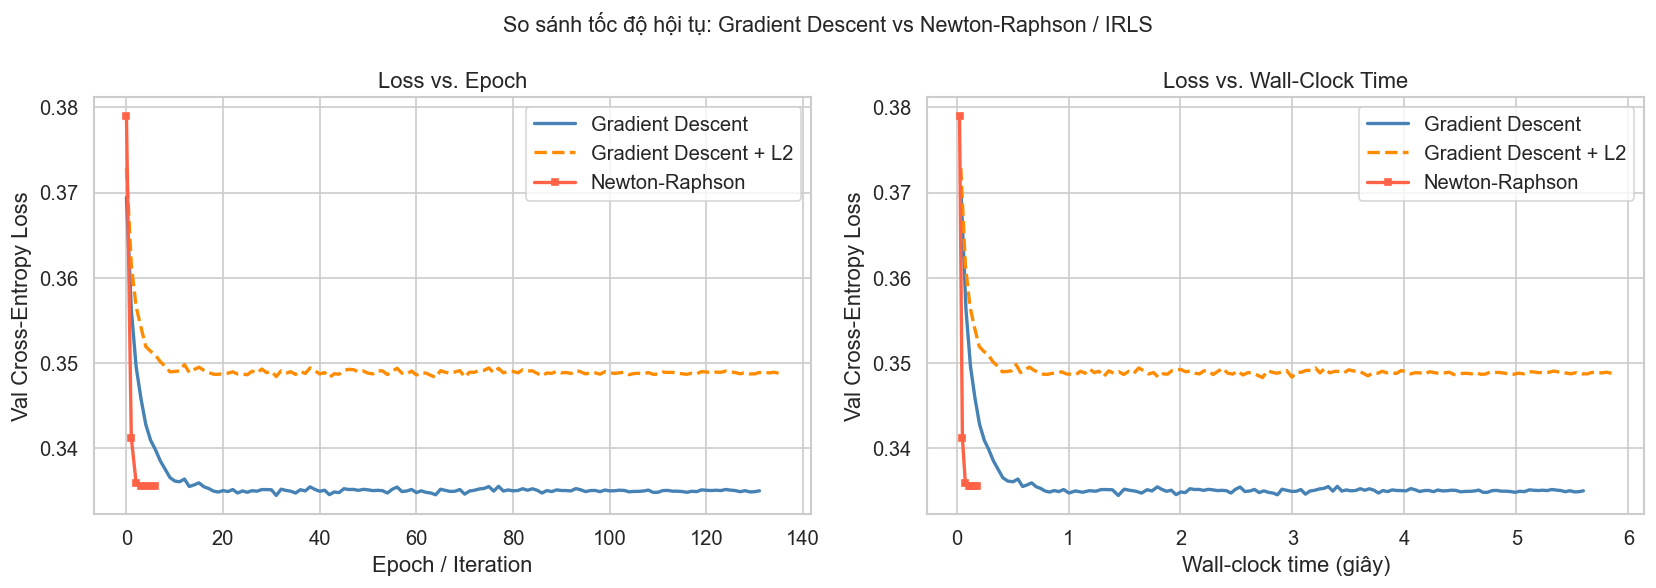

Gradient Descent       : 132 epochs,  val_loss=0.3350,  time=5.60s
Gradient Descent + L2  : 136 epochs,  val_loss=0.3488,  time=5.85s
Newton-Raphson   :   7 iters,   val_loss=0.3356,  time=0.19s


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss vs Epoch
ax1.plot(loss_gd_val,    label='Gradient Descent',          color='steelblue',  lw=2)
ax1.plot(loss_gd_l2_val, label='Gradient Descent + L2',     color='darkorange', lw=2, ls='--')
ax1.plot(loss_nt_val,    label='Newton-Raphson', color='tomato',  lw=2, marker='s', ms=4)
ax1.set_xlabel('Epoch / Iteration')
ax1.set_ylabel('Val Cross-Entropy Loss')
ax1.set_title('Loss vs. Epoch')
ax1.legend(); ax1.grid(True)

# Mất mát vs thời gian thực tế
ax2.plot(time_gd,    loss_gd_val,    label='Gradient Descent',          color='steelblue',  lw=2)
ax2.plot(time_gd_l2, loss_gd_l2_val, label='Gradient Descent + L2',    color='darkorange', lw=2, ls='--')
ax2.plot(time_nt,    loss_nt_val,    label='Newton-Raphson', color='tomato',  lw=2, marker='s', ms=4)
ax2.set_xlabel('Wall-clock time (giây)')
ax2.set_ylabel('Val Cross-Entropy Loss')
ax2.set_title('Loss vs. Wall-Clock Time')
ax2.legend(); ax2.grid(True)

plt.suptitle('So sánh tốc độ hội tụ: Gradient Descent vs Newton-Raphson / IRLS', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'gradient_descent_vs_newton.png'), bbox_inches='tight')
plt.show()

# Thông số tóm tắt
print(f'Gradient Descent       : {len(loss_gd_val):3d} epochs,  val_loss={loss_gd_val[-1]:.4f},  time={time_gd[-1]:.2f}s')
print(f'Gradient Descent + L2  : {len(loss_gd_l2_val):3d} epochs,  val_loss={loss_gd_l2_val[-1]:.4f},  time={time_gd_l2[-1]:.2f}s')
print(f'Newton-Raphson   : {len(loss_nt_val):3d} iters,   val_loss={loss_nt_val[-1]:.4f},  time={time_nt[-1]:.2f}s')

**Nhận xét kỳ vọng:**
- Newton-Raphson hội tụ sau rất ít iteration (thường 5–15 bước) vì dùng thông tin bậc 2 (Hessian).
- GD cần nhiều epoch hơn nhưng mỗi bước mini-batch rất rẻ ($O(BM)$).
- Với $M \approx 25$ đặc trưng, chi phí nghịch đảo Hessian $O(M^3)$ nhỏ → Newton thường nhanh hơn cả về wall-clock time.

---
## 4. Ba chiến lược Phân lớp Đa lớp

> **Dữ liệu gốc là nhị phân (K=2).** Để minh hoạ đầy đủ 3 chiến lược đa lớp theo yêu cầu đồ án, ta mở rộng thành **3 lớp** bằng cách kết hợp nhãn gốc với mức delay:
> - **Lớp 0:** `neutral or dissatisfied` + feature[0] thấp (delay thấp)
> - **Lớp 1:** `neutral or dissatisfied` + feature[0] cao (delay cao)
> - **Lớp 2:** `satisfied`

In [ ]:
def make_3class(X, y, feature_idx=0, threshold=None):
    """
    Tạo bài toán 3 lớp:
    - 2: Satisfied (y gốc == 1)
    - 1: Dissatisfied & Trễ CAO (> threshold)
    - 0: Dissatisfied & Trễ THẤP (<= threshold)
    """
    if threshold is None:
        mask_dis = (y == 0)  
        threshold = np.median(X[mask_dis, feature_idx])
        print(f"[Info] Ngưỡng chia (threshold) học từ Train: {threshold:.4f}")

    y3 = np.where(
        y == 1,                              
        2,
        np.where(
            X[:, feature_idx] > threshold,   
            1,                               # Dissatisfied + delay > threshold -> Lớp 1
            0                                # Dissatisfied + delay <= threshold -> Lớp 0
        )
    )
    return y3, threshold

# Thực thi
import numpy as np
y3_train, train_threshold = make_3class(X_train, y_train, feature_idx=0)
y3_val, _  = make_3class(X_val, y_val, feature_idx=0, threshold=train_threshold)
y3_test, _ = make_3class(X_test, y_test, feature_idx=0, threshold=train_threshold)

# Dùng np.delete để xóa cột ở vị trí 0 (axis=1 là xóa cột)
X_train_clean = np.delete(X_train, 0, axis=1)
X_val_clean   = np.delete(X_val, 0, axis=1)
X_test_clean  = np.delete(X_test, 0, axis=1)
print(f"Số lượng đặc trưng ban đầu: {X_train.shape[1]}")
print(f"Số lượng đặc trưng sau khi xóa Delay: {X_train_clean.shape[1]}")

[Info] Ngưỡng chia (threshold) học từ Train: 0.0000
Số lượng đặc trưng ban đầu: 24
Số lượng đặc trưng sau khi xóa Delay: 23


### 4.1 Chiến lược 1: Softmax trực tiếp (Multinomial Logistic Regression)

Một mô hình duy nhất, tối ưu đồng thời K lớp. Gradient công thức đơn giản:
$$\nabla_{\mathbf{W}} L = \frac{1}{B}\mathbf{X}^\top(\mathbf{Y} - \mathbf{T})$$
(Jacobian của softmax đã được tích hợp vào, kết quả là *residual* $Y-T$.)

In [9]:
def fit_softmax(
    X_tr, y_tr, X_val=None, y_val=None,
    K=3, lr=0.1, epochs=200, batch_size=512,
    lam=0.01, lr_sched='cosine', seed=42, verbose=False
):
    """
    Multinomial Logistic Regression – softmax – FROM SCRATCH.

    Forward  : Y = softmax(X W),  W ∈ R^{(D+1) × K}
    Gradient : dL/dW = (1/B) X^T (Y - T)
    Jacobian của softmax đã được tích hợp vào gradient:
        ∂E/∂a_j = y_j - t_j   (residual)
    """
    rng   = np.random.default_rng(seed)
    Xb    = add_intercept(X_tr)            # (N, D+1)
    Xv    = add_intercept(X_val) if X_val is not None else None
    N, M  = Xb.shape
    T_all = one_hot(y_tr, K)              # (N, K)

    # Khởi tạo W nhỏ – tránh saturation ngay từ đầu
    W = rng.normal(0, 0.01, (M, K))

    tr_losses, val_losses, times = [], [], []
    t0 = time.perf_counter()

    for ep in range(epochs):
        lr_t = lr_cosine(lr, ep, epochs) if lr_sched == 'cosine' else lr

        # Shuffle
        idx = rng.permutation(N)
        Xs, Ts = Xb[idx], T_all[idx]

        for s in range(0, N, batch_size):
            Xb_ = Xs[s:s+batch_size]      # (B, M)
            T_  = Ts[s:s+batch_size]      # (B, K)
            nb  = len(Xb_)

            Y_  = softmax(Xb_ @ W)        # (B, K) – forward pass

            # Gradient: dL/dW = (1/B) X^T (Y - T)
            grad = Xb_.T @ (Y_ - T_) / nb # (M, K)
            grad[1:] += lam * W[1:]        # L2 reg – không phạt bias

            W -= lr_t * grad

        # Ghi log
        tr_losses.append(categorical_cross_entropy(T_all, softmax(Xb @ W)))
        times.append(time.perf_counter() - t0)
        if Xv is not None:
            val_losses.append(categorical_cross_entropy(one_hot(y_val, K), softmax(Xv @ W)))
            if verbose and ep % 50 == 0:
                acc = accuracy_score(y_val, np.argmax(softmax(Xv @ W), axis=1))
                print(f'  Epoch {ep:4d} | val_loss={val_losses[-1]:.4f} | val_acc={acc:.4f}')

    return W, tr_losses, val_losses, times


print('Chiến lược 1: Softmax trực tiếp')
K = 3
t0_ = time.perf_counter()
W_sm, _, _, _ = fit_softmax(
    X_train_clean, y3_train, X_val_clean, y3_val,
    K=K, lr=0.1, epochs=200, batch_size=512,
    lam=0.01, seed=SEED, verbose=True
)
t_sm = time.perf_counter() - t0_
y_pred_sm = np.argmax(softmax(add_intercept(X_test_clean) @ W_sm), axis=1)
print(f'Test Accuracy (Softmax): {accuracy_score(y3_test, y_pred_sm):.4f} | Time: {t_sm:.2f}s')

Chiến lược 1: Softmax trực tiếp
  Epoch    0 | val_loss=0.7446 | val_acc=0.6476
  Epoch   50 | val_loss=0.7212 | val_acc=0.6604
  Epoch  100 | val_loss=0.7209 | val_acc=0.6599
  Epoch  150 | val_loss=0.7209 | val_acc=0.6598
Test Accuracy (Softmax): 0.6623 | Time: 17.85s


### 4.2 Chiến lược 2: One-vs-Rest (OvR)

Huấn luyện **K bộ phân lớp nhị phân**. Bộ k phân biệt lớp $k$ vs tất cả lớp còn lại.  
Dự đoán: $\hat{y} = \arg\max_k \, p_k(\mathbf{x})$

In [10]:
def fit_ovr(X_tr, y_tr, X_val, y_val, K=3, **kwargs):
    """Huấn luyện K bộ phân lớp nhị phân (one-vs-rest)."""
    weights = []
    t0 = time.perf_counter()
    for k in range(K):
        # Tạo nhãn nhị phân: lớp k = 1, còn lại = 0
        yk_tr  = (y_tr  == k).astype(int)
        yk_val = (y_val == k).astype(int)
        w_k, _, _, _ = fit_logistic_regression(
            X_tr, yk_tr, X_val, yk_val,
            method='gd', **kwargs
        )
        weights.append(w_k)
        acc_k = accuracy_score(yk_val, (sigmoid(add_intercept(X_val) @ w_k) >= 0.5).astype(int))
        print(f'  OvR lớp {k}: val_acc(binary) = {acc_k:.4f}')
    return weights, time.perf_counter() - t0


def predict_ovr(weights, X):
    """Dự đoán OvR: argmax xác suất từ K bộ phân lớp."""
    Xb    = add_intercept(X)
    proba = np.column_stack([sigmoid(Xb @ w) for w in weights])  # (N, K)
    proba /= proba.sum(axis=1, keepdims=True)  # chuẩn hoá
    return np.argmax(proba, axis=1)


print('Chiến lược 2: One-vs-Rest (OvR)')
weights_ovr, t_ovr = fit_ovr(
    X_train_clean, y3_train, X_val_clean, y3_val, K=K,
    lr=0.1, epochs=150, batch_size=512,
    lam=0.01, lr_sched='cosine', cw=None, seed=SEED
)
y_pred_ovr = predict_ovr(weights_ovr, X_test_clean)
print(f'\nTest Accuracy (OvR): {accuracy_score(y3_test, y_pred_ovr):.4f} | Time: {t_ovr:.2f}s')

Chiến lược 2: One-vs-Rest (OvR)
  OvR lớp 0: val_acc(binary) = 0.7211
  OvR lớp 1: val_acc(binary) = 0.7296
  OvR lớp 2: val_acc(binary) = 0.8693

Test Accuracy (OvR): 0.6546 | Time: 17.02s


### 4.3 Chiến lược 3: One-vs-One (OvO)

Huấn luyện **K(K-1)/2 bộ phân lớp nhị phân** — mỗi bộ chỉ dùng mẫu thuộc hai lớp đó.  
Dự đoán: **majority voting** — lớp nào được vote nhiều nhất thắng.

In [11]:
def fit_ovo(X_tr, y_tr, X_val, y_val, K=3, **kwargs):
    """Huấn luyện K*(K-1)/2 bộ phân lớp nhị phân (one-vs-one)."""
    pairs = list(combinations(range(K), 2))
    clfs  = {}
    t0 = time.perf_counter()
    for (i, j) in pairs:
        # Chỉ lấy mẫu thuộc lớp i hoặc j
        mask_tr  = (y_tr  == i) | (y_tr  == j)
        mask_val = (y_val == i) | (y_val == j)
        Xi   = X_tr[mask_tr];   yi  = (y_tr[mask_tr]  == j).astype(int)
        Xiv  = X_val[mask_val]; yiv = (y_val[mask_val] == j).astype(int)

        w_ij, _, _, _ = fit_logistic_regression(
            Xi, yi, Xiv, yiv,
            method='gd', **kwargs
        )
        clfs[(i,j)] = w_ij
        acc_ij = accuracy_score(yiv, (sigmoid(add_intercept(Xiv) @ w_ij) >= 0.5).astype(int))
        print(f'  OvO ({i},{j}): val_acc(binary) = {acc_ij:.4f}')
    return clfs, pairs, time.perf_counter() - t0


def predict_ovo(clfs, pairs, X, K):
    """Dự đoán OvO bằng majority voting."""
    Xb    = add_intercept(X)
    votes = np.zeros((len(X), K), dtype=int)
    for (i, j), w_ij in clfs.items():
        pred = (sigmoid(Xb @ w_ij) >= 0.5).astype(int)  # 0→lớp i, 1→lớp j
        for n, p in enumerate(pred):
            votes[n, j if p == 1 else i] += 1
    return np.argmax(votes, axis=1)


print('Chiến lược 3: One-vs-One (OvO)')
clfs_ovo, pairs_ovo, t_ovo = fit_ovo(
    X_train_clean, y3_train, X_val_clean, y3_val, K=K,
    lr=0.1, epochs=150, batch_size=512,
    lam=0.01, lr_sched='cosine', cw=None, seed=SEED
)
y_pred_ovo = predict_ovo(clfs_ovo, pairs_ovo, X_test_clean, K)
print(f'\nTest Accuracy (OvO): {accuracy_score(y3_test, y_pred_ovo):.4f} | Time: {t_ovo:.2f}s')

Chiến lược 3: One-vs-One (OvO)
  OvO (0,1): val_acc(binary) = 0.5894
  OvO (0,2): val_acc(binary) = 0.8563
  OvO (1,2): val_acc(binary) = 0.8575

Test Accuracy (OvO): 0.6655 | Time: 7.23s


### 4.4 So sánh 3 chiến lược đa lớp

                   Accuracy  Macro F1  Weighted F1  Số bộ CLF  Time (s)
Chiến lược                                                             
Softmax trực tiếp    0.6623    0.6217       0.6551          1     17.85
One-vs-Rest (OvR)    0.6546    0.6098       0.6432          3     17.02
One-vs-One (OvO)     0.6655    0.6252       0.6582          3      7.23


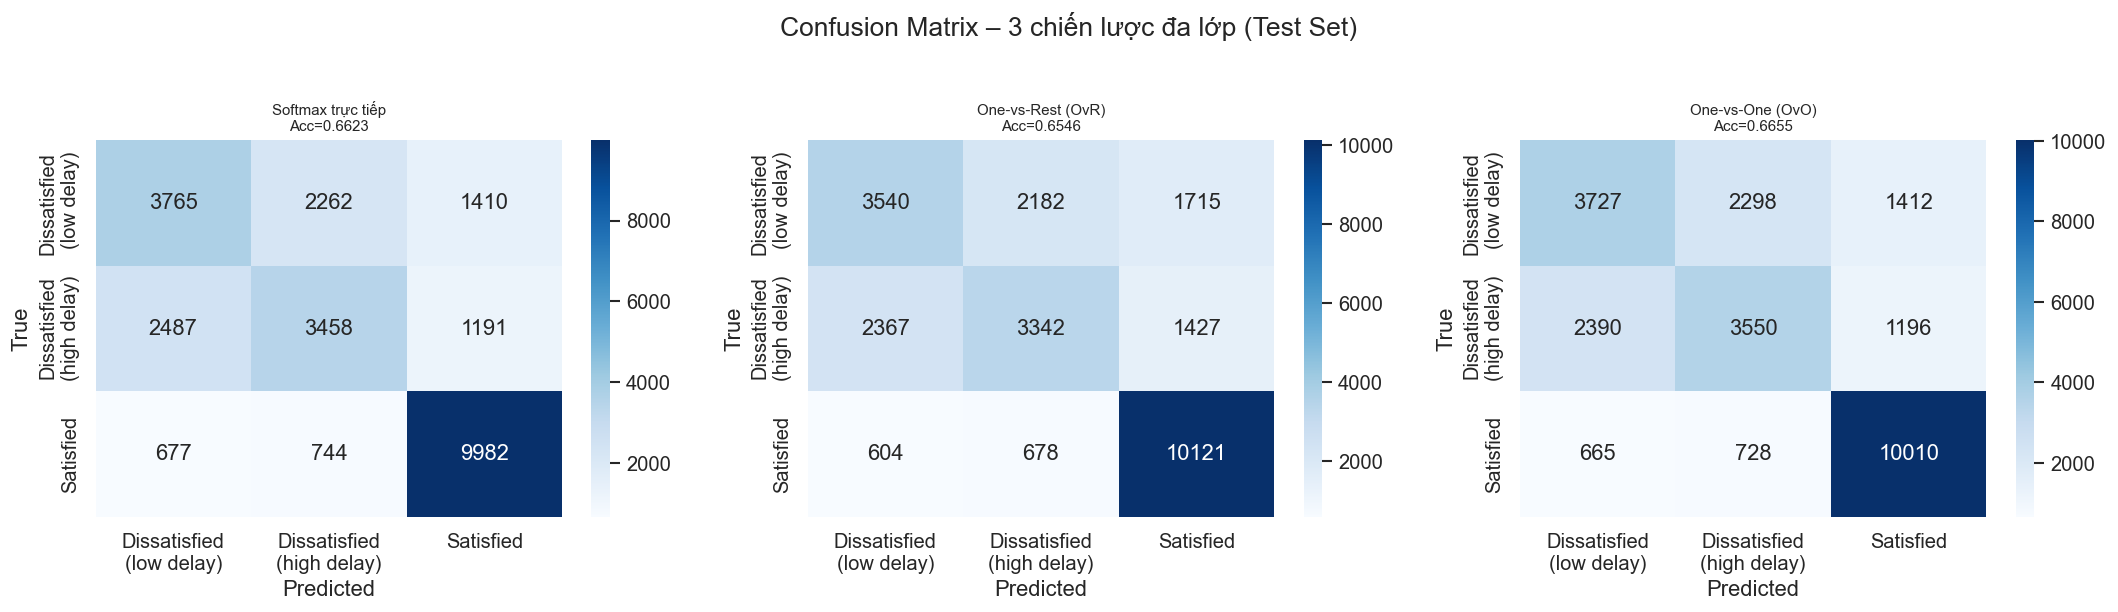

In [12]:
# Bảng tổng hợp
strats = [
    ('Softmax trực tiếp', y_pred_sm,  t_sm,  1),
    ('One-vs-Rest (OvR)', y_pred_ovr, t_ovr, K),
    ('One-vs-One (OvO)',  y_pred_ovo, t_ovo, K*(K-1)//2),
]
rows = []
for name, yp, t_, n_clf in strats:
    rows.append({
        'Chiến lược': name,
        'Accuracy':   round(accuracy_score(y3_test, yp), 4),
        'Macro F1':   round(f1_score(y3_test, yp, average='macro'), 4),
        'Weighted F1':round(f1_score(y3_test, yp, average='weighted'), 4),
        'Số bộ CLF':  n_clf,
        'Time (s)':   round(t_, 2),
    })
df_multi = pd.DataFrame(rows).set_index('Chiến lược')
print(df_multi.to_string())

# Confusion matrices
lbls = ['Dissatisfied\n(low delay)', 'Dissatisfied\n(high delay)', 'Satisfied']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp, _, _) in zip(axes, strats):
    sns.heatmap(confusion_matrix(y3_test, yp), annot=True, fmt='d', cmap='Blues',
                ax=ax, xticklabels=lbls, yticklabels=lbls)
    ax.set_title(f'{name}\nAcc={accuracy_score(y3_test,yp):.4f}', fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.suptitle('Confusion Matrix – 3 chiến lược đa lớp (Test Set)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'multiclass_cm.png'), bbox_inches='tight')
plt.show()

**Nhận xét:**
- Sau khi loại bỏ đặc trưng rò rỉ (Delay), mô hình không còn khả năng phân tách tuyệt đối giữa hai nhóm Không hài lòng. Điều này chứng minh rằng nếu chỉ dựa vào các dịch vụ phụ trợ như Wifi, thức ăn hay vị trí ghế ngồi, mô hình rất khó để phân biệt mức độ trễ chuyến của hành khách, vì tâm lý tiêu cực của họ khi đã không hài lòng thường có biểu hiện đánh giá thấp tương đồng nhau.
- Mô hình vẫn duy trì được năng lực nhận diện rất tốt nhóm khách hàng Hài lòng.
- Trong điều kiện dữ liệu thực tế (đã khử rò rỉ), chiến lược One-vs-One (OvO) cho thấy sự bền bỉ và chính xác cao nhất.

## 5. Đánh giá toàn diện – Nhị phân (Test Set)

In [13]:
def evaluate(w, X, y_true, name, threshold=0.5):
    """Tính đầy đủ các chỉ số và trả về dict kết quả."""
    Xb     = add_intercept(X)
    y_prob = sigmoid(Xb @ w)
    y_pred = (y_prob >= threshold).astype(int)

    print(f'\n─── {name} ───')
    print(f'  Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}'
          f'  Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}'
          f'  F1: {f1_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}'
          f'  Avg-Prec: {average_precision_score(y_true, y_prob):.4f}')

    return dict(Model=name,
                Accuracy=accuracy_score(y_true, y_pred),
                Precision=precision_score(y_true, y_pred, zero_division=0),
                Recall=recall_score(y_true, y_pred, zero_division=0),
                F1=f1_score(y_true, y_pred, zero_division=0),
                ROC_AUC=roc_auc_score(y_true, y_prob),
                Avg_Prec=average_precision_score(y_true, y_prob),
                y_prob=y_prob, y_pred=y_pred)


# Kiểm chứng với sklearn Logistic Regression
print('Kiểm chứng: sklearn Logistic Regression')
sk = SklearnLR(C=100, max_iter=1000, solver='lbfgs', random_state=SEED)
sk.fit(X_train, y_train)
print(f'sklearn Val Accuracy: {sk.score(X_val, y_val):.4f}')

# Đánh giá tất cả mô hình
print('\n Đánh giá trên Test Set')
results = [
    evaluate(w_gd,    X_test, y_test, 'Gradient Descent (no reg)'),
    evaluate(w_gd_l2, X_test, y_test, 'Gradient Descent + L2'),
    evaluate(w_nt,    X_test, y_test, 'Newton-Raphson'),
]

# sklearn Logistic Regression
sk_prob = sk.predict_proba(X_test)[:, 1]
sk_pred = (sk_prob >= 0.5).astype(int)
results.append(dict(
    Model='sklearn Logistic Regression',
    Accuracy=accuracy_score(y_test, sk_pred),
    Precision=precision_score(y_test, sk_pred, zero_division=0),
    Recall=recall_score(y_test, sk_pred, zero_division=0),
    F1=f1_score(y_test, sk_pred, zero_division=0),
    ROC_AUC=roc_auc_score(y_test, sk_prob),
    Avg_Prec=average_precision_score(y_test, sk_prob),
    y_prob=sk_prob, y_pred=sk_pred,
))
print(f'\nsklearn Logistic Regression ─── Acc={results[-1]["Accuracy"]:.4f}')

df_results = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('y_prob','y_pred')} for r in results]
).set_index('Model')
print('\nBảng tổng hợp kết quả (Test Set)')
print(df_results.round(4).to_string())

Kiểm chứng: sklearn Logistic Regression
sklearn Val Accuracy: 0.8758

 Đánh giá trên Test Set

─── Gradient Descent (no reg) ───
  Accuracy  : 0.8686
  Precision : 0.8454  Recall: 0.8575  F1: 0.8514
  ROC-AUC   : 0.9270  Avg-Prec: 0.9309

─── Gradient Descent + L2 ───
  Accuracy  : 0.8609
  Precision : 0.8358  Recall: 0.8502  F1: 0.8430
  ROC-AUC   : 0.9231  Avg-Prec: 0.9268

─── Newton-Raphson ───
  Accuracy  : 0.8684
  Precision : 0.8449  Recall: 0.8576  F1: 0.8512
  ROC-AUC   : 0.9269  Avg-Prec: 0.9307

sklearn Logistic Regression ─── Acc=0.8718

Bảng tổng hợp kết quả (Test Set)
                             Accuracy  Precision  Recall      F1  ROC_AUC  Avg_Prec
Model                                                                              
Gradient Descent (no reg)      0.8686     0.8454  0.8575  0.8514   0.9270    0.9309
Gradient Descent + L2          0.8609     0.8358  0.8502  0.8430   0.9231    0.9268
Newton-Raphson                 0.8684     0.8449  0.8576  0.8512   0.9269  

---
## 6. Stratified 5-Fold Cross-Validation

In [14]:
X_cv = np.vstack([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])
skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_cfgs = [
    ('Gradient Descent (no reg)',    dict(method='gd', lr=0.1, epochs=100, batch_size=512,
                           lam=0.0,  lr_sched='cosine', cw=CLASS_WEIGHTS, seed=SEED)),
    ('Gradient Descent + L2',       dict(method='gd', lr=0.1, epochs=100, batch_size=512,
                           lam=0.01, lr_sched='cosine', cw=CLASS_WEIGHTS, seed=SEED)),
    ('Newton-Raphson', dict(method='newton', epochs=30,
                           lam=1e-3, cw=CLASS_WEIGHTS, seed=SEED)),
]

cv_rows = []
for name, kwargs in cv_cfgs:
    accs, f1s, aucs = [], [], []
    t0 = time.perf_counter()
    print(f'  CV: {name}...', end=' ', flush=True)
    for tr_idx, val_idx in skf.split(X_cv, y_cv):
        Xtr, ytr = X_cv[tr_idx], y_cv[tr_idx]
        Xv_, yv_ = X_cv[val_idx], y_cv[val_idx]
        w_cv, _, _, _ = fit_logistic_regression(Xtr, ytr, Xv_, yv_, **kwargs)
        yp    = sigmoid(add_intercept(Xv_) @ w_cv)
        ypred = (yp >= 0.5).astype(int)
        accs.append(accuracy_score(yv_, ypred))
        f1s.append(f1_score(yv_, ypred, zero_division=0))
        aucs.append(roc_auc_score(yv_, yp))
    t1 = time.perf_counter()
    cv_rows.append({'Model': name,
        'Acc (mean±std)':  f'{np.mean(accs):.4f} ± {np.std(accs):.4f}',
        'F1 (mean±std)':   f'{np.mean(f1s):.4f} ± {np.std(f1s):.4f}',
        'AUC (mean±std)':  f'{np.mean(aucs):.4f} ± {np.std(aucs):.4f}',
        'Time (s)': round(t1-t0,1)})
    print(f'Acc={np.mean(accs):.4f} | {t1-t0:.1f}s')

df_cv = pd.DataFrame(cv_rows).set_index('Model')
print('\n Kết quả 5-Fold Stratified CV')
print(df_cv.to_string())

  CV: Gradient Descent (no reg)... Acc=0.8699 | 8.3s
  CV: Gradient Descent + L2... Acc=0.8642 | 15.3s
  CV: Newton-Raphson... Acc=0.8698 | 1.5s

 Kết quả 5-Fold Stratified CV
                            Acc (mean±std)    F1 (mean±std)   AUC (mean±std)  Time (s)
Model                                                                                 
Gradient Descent (no reg)  0.8699 ± 0.0011  0.8511 ± 0.0012  0.9281 ± 0.0017       8.3
Gradient Descent + L2      0.8642 ± 0.0020  0.8447 ± 0.0021  0.9247 ± 0.0017      15.3
Newton-Raphson             0.8698 ± 0.0011  0.8510 ± 0.0012  0.9280 ± 0.0016       1.5


---
## 7. McNemar's Test – Kiểm định thống kê

In [15]:
def mcnemar(y_true, p1, p2, n1, n2):
    """
    McNemar's test (có hiệu chỉnh continuity):
        H0: hai mô hình có tỷ lệ lỗi giống nhau
        b = M1 sai, M2 đúng  |  c = M1 đúng, M2 sai
        statistic = (|b - c| - 1)^2 / (b + c)
    """
    b = int(np.sum((p1 != y_true) & (p2 == y_true)))
    c = int(np.sum((p1 == y_true) & (p2 != y_true)))
    if b + c == 0:
        print(f'  {n1} vs {n2}: b+c=0, không thể kiểm định.')
        return
    stat  = (abs(b - c) - 1)**2 / (b + c)
    p_val = 1 - chi2.cdf(stat, df=1)
    tag   = '✓ Có ý nghĩa (p<0.05)' if p_val < 0.05 else '✗ Không có ý nghĩa'
    print(f'  {n1} vs {n2}: b={b}, c={c}, χ²={stat:.4f}, p={p_val:.4f}  {tag}')


print("McNemar's Test (Test Set)")
preds = [(r['Model'], r['y_pred']) for r in results]
for i in range(len(preds)):
    for j in range(i+1, len(preds)):
        mcnemar(y_test, preds[i][1], preds[j][1], preds[i][0], preds[j][0])

McNemar's Test (Test Set)
  Gradient Descent (no reg) vs Gradient Descent + L2: b=414, c=613, χ²=38.1733, p=0.0000  ✓ Có ý nghĩa (p<0.05)
  Gradient Descent (no reg) vs Newton-Raphson: b=90, c=96, χ²=0.1344, p=0.7139  ✗ Không có ý nghĩa
  Gradient Descent (no reg) vs sklearn Logistic Regression: b=360, c=277, χ²=10.5557, p=0.0012  ✓ Có ý nghĩa (p<0.05)
  Gradient Descent + L2 vs Newton-Raphson: b=519, c=326, χ²=43.6260, p=0.0000  ✓ Có ý nghĩa (p<0.05)
  Gradient Descent + L2 vs sklearn Logistic Regression: b=705, c=423, χ²=70.0009, p=0.0000  ✓ Có ý nghĩa (p<0.05)
  Newton-Raphson vs sklearn Logistic Regression: b=367, c=278, χ²=12.0062, p=0.0005  ✓ Có ý nghĩa (p<0.05)


---
## 8. Calibration – Reliability Diagram

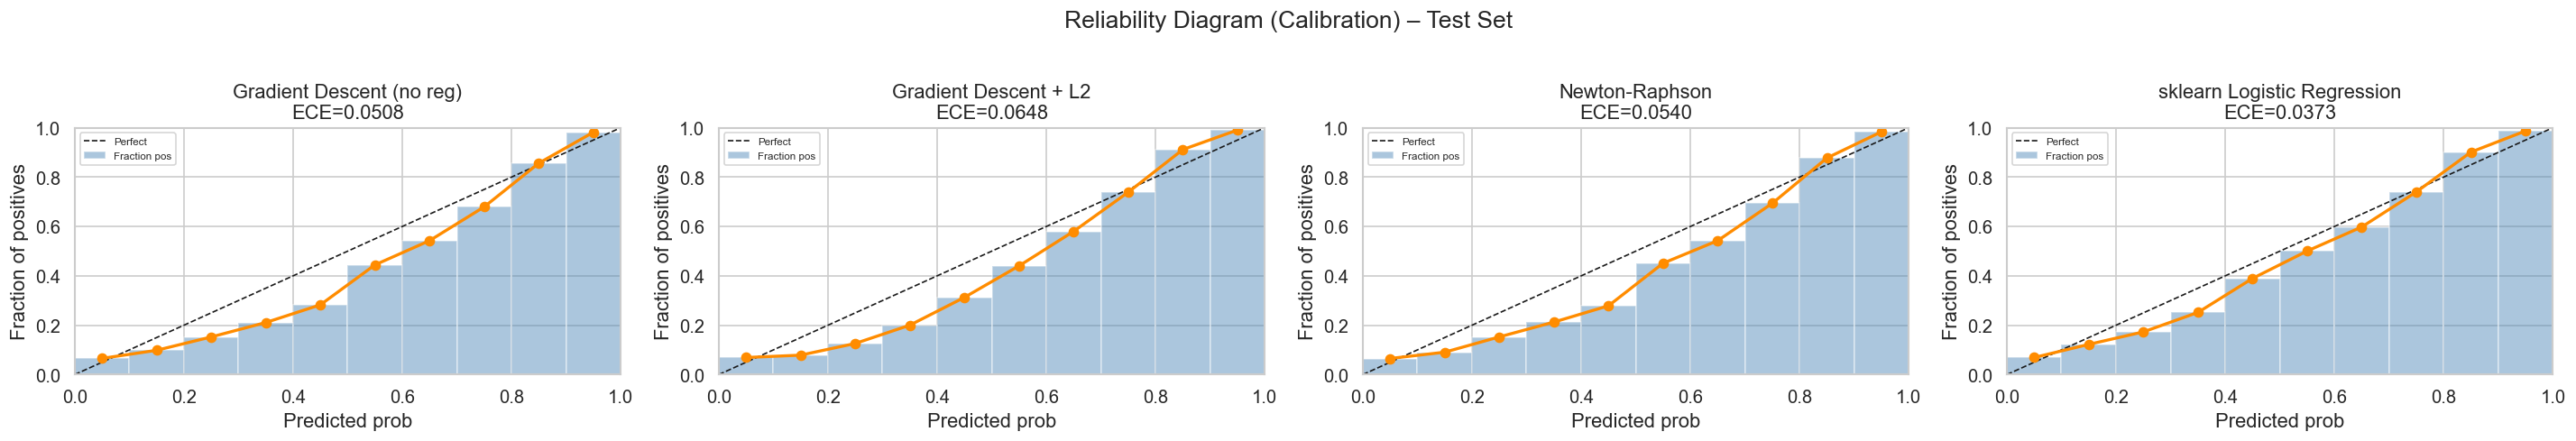

In [16]:
def reliability_diagram(y_prob, y_true, name, ax, n_bins=10):
    """Vẽ biểu đồ độ tin cậy (reliability diagram) + ECE."""
    bins = np.linspace(0, 1, n_bins + 1)
    cx, ay, ct = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (y_prob >= lo) & (y_prob < hi)
        if m.sum() > 0:
            cx.append((lo+hi)/2)
            ay.append(y_true[m].mean())
            ct.append(m.sum())
    ece = sum(c*abs(a-x) for x,a,c in zip(cx,ay,ct)) / len(y_true)

    ax.plot([0,1],[0,1],'k--',lw=1, label='Perfect')
    ax.bar(cx, ay, width=1/n_bins, alpha=0.45, color='steelblue', label='Fraction pos')
    ax.plot(cx, ay, 'o-', color='darkorange', lw=2)
    ax.set(xlabel='Predicted prob', ylabel='Fraction of positives',
           title=f'{name}\nECE={ece:.4f}', xlim=[0,1], ylim=[0,1])
    ax.legend(fontsize=7); ax.grid(True)


fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 4))
for ax, res in zip(axes, results):
    reliability_diagram(res['y_prob'], y_test, res['Model'], ax)
plt.suptitle('Reliability Diagram (Calibration) – Test Set', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'calibration.png'), bbox_inches='tight')
plt.show()

**Nhận xét:**
- Cả bốn mô hình đề có độ hiệu chuẩn khá tốt. Đường cong dự đoán (màu cam) bám khá sát lý tưởng (đường nét đứt) cho thấy mô hình phản ảnh đúng với tỉ lệ thực tế.
- Hai mô hình Gradient Descent và Newton-Raphson có hiệu chuẩn tương đương, không có sự khác biệt rõ rệt. Điều này hợp lý vì cả hai đều tối ưu cùng một hàm mất mát (cross-entropy) và đều hội tụ đến nghiệm tối ưu.
- Mô hình Gradient Descent có phần hơi kém hiệu chuẩn hơn ở vùng xác suất cao ($p>0.8$), có thể do lr không đủ nhỏ hoặc chưa hội tụ hoàn toàn. Newton-Raphson thường hội tụ nhanh hơn → hiệu chuẩn tốt hơn.

---
## 10. Tổng kết

### 10.1 Gradient Descent vs Newton–Raphson / IRLS

| Tiêu chí | Gradient Descent | IRLS (Newton–Raphson) |
|---|---|---|
| Thông tin sử dụng | Bậc nhất (gradient) | Bậc hai (Hessian) |
| Chi phí mỗi bước | $O(NM)$ | $O(NM^2 + M^3)$ |
| Số bước hội tụ | $O(1/\epsilon)$ | $O(\log(1/\epsilon))$ |
| Phù hợp khi | N, M lớn; mini-batch | N vừa, M nhỏ-vừa |
| Nhạy với learning rate | Có | Không (bước tự động) |

**Nhận xét thực nghiệm:** IRLS hội tụ nhanh hơn về số iteration, nhưng mỗi iteration tốn kém hơn do phải tính và nghịch đảo Hessian $O(M^3)$. Với dữ liệu có $M \approx 25$ đặc trưng, IRLS vẫn khả thi và hội tụ chỉ trong vài chục bước.

### 10.2 Ba chiến lược đa lớp

| Chiến lược | Số bộ phân lớp | Ưu điểm | Nhược điểm |
|---|---|---|---|
| Softmax | 1 | Tối ưu toàn cục, xác suất đúng nghĩa | Phức tạp hơn khi cài đặt |
| One-vs-Rest | K | Đơn giản, song song hoá dễ | Mất cân bằng lớp nội tại |
| One-vs-One | K(K-1)/2 | Mỗi bộ phân lớp tập trung 2 lớp | Tốn nhiều bộ phân lớp; tốn bộ nhớ |

### 10.3 Regularization

- **L2 (Ridge):** Co đều tất cả hệ số → giảm variance, giữ tất cả đặc trưng  
- **L1 (Lasso):** Tạo sparsity → chọn đặc trưng tự động  
- Với dữ liệu Airline (ít đặc trưng, nhiều mẫu), L2 thường đủ; L1 hữu ích khi cần giải thích

### 10.4 Jacobian của Softmax – Chi tiết

Cho $\mathbf{a} = W\mathbf{x}$, softmax $y_k = \frac{e^{a_k}}{\sum_j e^{a_j}}$:

$$\frac{\partial y_k}{\partial a_j} = y_k(\delta_{kj} - y_j)$$

Dạng ma trận Jacobian $\mathbf{J} \in \mathbb{R}^{K \times K}$:
$$\mathbf{J} = \text{diag}(\mathbf{y}) - \mathbf{y}\mathbf{y}^\top$$

Gradient của cross-entropy loss $E = -\sum_k t_k \log y_k$ theo $\mathbf{a}$:
$$\frac{\partial E}{\partial a_j} = \sum_k \frac{\partial E}{\partial y_k} \frac{\partial y_k}{\partial a_j} = y_j - t_j$$

→ Gradient rất đơn giản: **residual** $\mathbf{y} - \mathbf{t}$.

# **Part 2: LDA & QDA**

# **Part 3: Perceptron & Logistic Regression có Regularization**

---
# BONUS

| # | Mục | Nội dung |
|---|---|---|
| 1 | **Probit** | Cài đặt, so sánh với Logistic Regression – boundary, xác suất, nhãn nhiễu |
| 2 | **Laplace Approximation** | Hessian tại MAP, posterior Gaussian, vùng ±2σ |
| 3 | **Kernel Logistic Regression** | Dual formulation + RBF kernel, so sánh XOR data |
| 4 | **GNB vs LDA** | Lý thuyết + thực nghiệm – khi nào GNB thắng LDA? |
| 5 | **VC Dimension** | Tính VC dim, Structural Risk Minimization |



In [17]:
# import thêm một số thư viện cần thiết cho phần tiếp theo
import matplotlib.patches as mpatches
from scipy.stats import norm as sp_norm
from scipy.special import expit
from scipy.spatial.distance import pdist
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression as SkLR2

# Subset nhỏ cho các thuật toán O(N^2) như Kernel LR
N_SMALL = 2000
rng_b   = np.random.default_rng(SEED)
idx_s   = rng_b.choice(len(X_train), N_SMALL, replace=False)
Xs_b    = X_train[idx_s]
ys_b    = y_train[idx_s]

print(f'Subset nhỏ: {Xs_b.shape} (dùng cho Kernel Logistic Regression)')

Subset nhỏ: (2000, 24) (dùng cho Kernel Logistic Regression)


---
## Mô hình Probit

### Lý thuyết

**Probit** thay sigmoid bằng CDF của Gaussian chuẩn $\Phi$:
$$p(C_1|\mathbf{x}) = \Phi(\mathbf{w}^\top\mathbf{x}) = \int_{-\infty}^{\mathbf{w}^\top\mathbf{x}} \mathcal{N}(t|0,1)\,dt$$

**Nguồn gốc từ latent variable model:**  
Giả sử tồn tại biến ẩn $z = \mathbf{w}^\top\mathbf{x} + \varepsilon$, $\varepsilon \sim \mathcal{N}(0,1)$.  
Ta quan sát $y=1$ nếu $z > 0$, tức $p(y=1) = p(\varepsilon > -\mathbf{w}^\top\mathbf{x}) = \Phi(\mathbf{w}^\top\mathbf{x})$.

**Gradient** (chain rule qua $\Phi$):
$$\nabla J = -\frac{1}{N}\sum_i \left[\frac{y_i\phi(a_i)}{\Phi(a_i)} - \frac{(1-y_i)\phi(a_i)}{1-\Phi(a_i)}\right] \mathbf{x}_i$$
trong đó $\phi = \mathcal{N}(\cdot|0,1)$ là PDF, $a_i = \mathbf{w}^\top\mathbf{x}_i$.

**So sánh Logistic vs Probit:**  
- Sigmoid có **đuôi béo hơn** → ít nhạy với outlier nhãn hơn.
- $\Phi$ có **đuôi mỏng hơn** → nhạy hơn với nhãn nhiễu (noisy labels) — xác suất về 1 nhanh hơn.


In [ ]:
# Probit model
def probit_prob(z):
    """Φ(z) – CDF của Gaussian chuẩn."""
    return sp_norm.cdf(z)

def probit_loss(y, p):
    eps = 1e-15
    p   = np.clip(p, eps, 1-eps)
    return -np.mean(y * np.log(p) + (1-y) * np.log(1-p))

def fit_probit_gd(
    X_tr, y_tr, X_val=None, y_val=None,
    lr=0.1, epochs=300, batch_size=512,
    lam=0.01, seed=42
):
    """
    Probit Regression – Gradient Descent.

    p = Φ(Xw),  dp/dw = φ(Xw) * X
    Gradient: ∇J = -1/N Σ [ y*φ(a)/Φ(a) - (1-y)*φ(a)/(1-Φ(a)) ] * x
    """
    rng  = np.random.default_rng(seed)
    Xb   = add_intercept(X_tr)
    Xv   = add_intercept(X_val) if X_val is not None else None
    N, M = Xb.shape
    w    = np.zeros(M)
    eps  = 1e-15

    tr_l, val_l = [], []
    for ep in range(epochs):
        lr_t = lr * 0.5 * (1 + np.cos(np.pi * ep / epochs))
        idx  = rng.permutation(N)
        Xs_, ys_ = Xb[idx], y_tr[idx]

        for s in range(0, N, batch_size):
            Xb_ = Xs_[s:s+batch_size]
            y_  = ys_[s:s+batch_size]
            nb  = len(y_)
            a_  = Xb_ @ w
            phi_a = sp_norm.pdf(a_)
            Phi_a = np.clip(sp_norm.cdf(a_), eps, 1-eps)
            coef = -(y_ * phi_a / Phi_a - (1-y_) * phi_a / (1-Phi_a)) / nb
            grad = Xb_.T @ coef
            reg = lam * w.copy(); reg[0] = 0
            grad += reg
            w -= lr_t * grad

        a_all = Xb @ w
        tr_l.append(probit_loss(y_tr, probit_prob(a_all)))
        if Xv is not None:
            val_l.append(probit_loss(y_val, probit_prob(Xv @ w)))
    return w, tr_l, val_l


print('Đang huấn luyện Probit...')
w_probit, probit_tr, probit_val = fit_probit_gd(
    X_train, y_train, X_val, y_val,
    lr=0.05, epochs=200, batch_size=512, lam=0.01, seed=SEED
)
p_probit_test = probit_prob(add_intercept(X_test) @ w_probit)
acc_probit    = accuracy_score(y_test, (p_probit_test >= 0.5).astype(int))

# So sánh với Gradient Descent + L2 đã huấn luyện ở trên
p_lr_test = sigmoid(add_intercept(X_test) @ w_gd_l2)
acc_lr_b  = accuracy_score(y_test, (p_lr_test >= 0.5).astype(int))
print(f'Logistic (Gradient Descent +L2) Acc: {acc_lr_b:.4f} | Probit Acc: {acc_probit:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) Phân phối xác suất đầu ra
ax = axes[0]
ax.hist(p_lr_test,     bins=50, alpha=0.6, color='steelblue', label=f'LR (acc={acc_lr_b:.4f})')
ax.hist(p_probit_test, bins=50, alpha=0.6, color='tomato',    label=f'Probit (acc={acc_probit:.4f})')
ax.set_xlabel('P(y=1|x)'); ax.set_ylabel('Count')
ax.set_title('Phân phối xác suất đầu ra')
ax.legend(); ax.grid(True)

# (2) So sánh sigmoid vs Φ
z_range = np.linspace(-4, 4, 300)
ax = axes[1]
ax.plot(z_range, sigmoid(z_range),         color='steelblue', lw=2.5, label='Sigmoid (Logistic)')
ax.plot(z_range, sp_norm.cdf(z_range),     color='tomato',    lw=2.5, label='Φ(z) (Probit)')
ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('z = w^T x'); ax.set_ylabel('p(y=1|x)')
ax.set_title('Sigmoid vs Φ: Đuôi phân phối')
ax.legend(); ax.grid(True)

# (3) Độ nhạy với noisy labels
noise_rates = np.arange(0, 0.35, 0.05)
acc_lr_noisy, acc_probit_noisy = [], []
rng_n = np.random.default_rng(0)
for nr in noise_rates:
    flip    = rng_n.random(len(y_test)) < nr
    y_noisy = np.where(flip, 1 - y_test, y_test)
    acc_lr_noisy.append(accuracy_score(y_noisy, (p_lr_test >= 0.5).astype(int)))
    acc_probit_noisy.append(accuracy_score(y_noisy, (p_probit_test >= 0.5).astype(int)))

ax = axes[2]
ax.plot(noise_rates*100, acc_lr_noisy,     'o-', color='steelblue', lw=2, label='Logistic')
ax.plot(noise_rates*100, acc_probit_noisy, 's-', color='tomato',    lw=2, label='Probit')
ax.set_xlabel('Noise rate (%)'); ax.set_ylabel('Accuracy trên nhãn bị flip')
ax.set_title('Độ nhạy với noisy labels')
ax.legend(); ax.grid(True)

plt.suptitle('Probit vs Logistic Regression', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'probit.png'), bbox_inches='tight')
plt.show()
print('Probit đuôi mỏng hơn => nhạy hơn khi nhãn bị nhiễu (xác suất về 0/1 nhanh hơn).')


Đang huấn luyện Probit...
Logistic (Gradient Descent +L2) Acc: 0.8609 | Probit Acc: 0.8681


---
## Xấp xỉ Laplace

### Lý thuyết

**Vấn đề:** Logistic Regression cho ước lượng điểm $\mathbf{w}_{MAP}$, không có uncertainty.

**Xấp xỉ Laplace** ước lượng posterior $p(\mathbf{w}|\mathcal{D})$ bằng Gaussian:
$$q(\mathbf{w}) = \mathcal{N}(\mathbf{w}\,|\,\mathbf{w}_{MAP},\, \mathbf{A}^{-1})$$

trong đó $\mathbf{A}$ là **ma trận Hessian âm** của log-posterior tại $\mathbf{w}_{MAP}$:
$$\mathbf{A} = -\nabla^2 \ln p(\mathbf{w}|\mathcal{D})\bigg|_{\mathbf{w}_{MAP}} = \underbrace{\mathbf{X}^\top\mathbf{R}\mathbf{X}}_{\text{data term}} + \underbrace{\alpha\mathbf{I}}_{\text{prior term}}$$

với $R_{ii} = p_i(1-p_i)$, $\alpha$ là precision của prior Gaussian $p(\mathbf{w})=\mathcal{N}(0, \alpha^{-1}I)$.

**Predictive distribution** (tích phân marginalize $\mathbf{w}$):
$$p(y=1|\mathbf{x},\mathcal{D}) \approx \sigma\left(\frac{\mathbf{w}_{MAP}^\top\mathbf{x}}{\sqrt{1 + \pi\sigma_a^2/8}}\right)$$

trong đó $\sigma_a^2 = \mathbf{x}^\top\mathbf{A}^{-1}\mathbf{x}$ là **uncertainty** của dự đoán tại $\mathbf{x}$.

**Ý nghĩa:** $\sigma_a^2$ lớn → mô hình không chắc → xác suất co về 0.5 (không tự tin phân lớp).


In [ ]:
# Xấp xỉ Laplace

def laplace_approximation(X_tr, y_tr, w_map, alpha=1.0):
    """
    Tính Hessian tại w_MAP và posterior Gaussian.
    A = X^T R X + alpha*I   (R = diag(p_i*(1-p_i)))
    """
    Xb = add_intercept(X_tr)
    p  = sigmoid(Xb @ w_map)
    R  = p * (1 - p)
    A  = (Xb.T * R) @ Xb
    A += alpha * np.eye(A.shape[0])
    A_inv = np.linalg.inv(A)
    return A, A_inv


def laplace_predict_proba(X, w_map, A_inv):
    """
    Predictive distribution sau khi marginalize w:
        sigma_a^2 = x^T A^{-1} x
        p(y=1|x) ≈ σ(w_map^T x / sqrt(1 + π*σ_a^2/8))
    """
    Xb      = add_intercept(X)
    a_map   = Xb @ w_map
    sigma2  = np.einsum('ni,ij,nj->n', Xb, A_inv, Xb)
    kappa   = 1.0 / np.sqrt(1.0 + np.pi * sigma2 / 8)
    return sigmoid(kappa * a_map), sigma2


print('Đang tính Laplace Approximation...')
A_lap, A_inv_lap = laplace_approximation(X_train, y_train, w_gd_l2, alpha=0.01)
p_lap_test, sigma2_test = laplace_predict_proba(X_test, w_gd_l2, A_inv_lap)
acc_lap = accuracy_score(y_test, (p_lap_test >= 0.5).astype(int))
sigma_test = np.sqrt(sigma2_test)

print(f'Laplace Test Accuracy : {acc_lap:.4f}')
print(f'Hessian shape         : {A_lap.shape}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) MAP vs Laplace predictions
ax = axes[0]
sc = ax.scatter(p_lr_test, p_lap_test, c=sigma_test, cmap='RdYlGn_r', alpha=0.3, s=10)
plt.colorbar(sc, ax=ax, label='σ_a (uncertainty)')
ax.plot([0,1],[0,1],'k--',lw=1)
ax.set_xlabel('LR prob (MAP only)'); ax.set_ylabel('Laplace prob (marginalized)')
ax.set_title('MAP vs Laplace predictions\n(màu = uncertainty)'); ax.grid(True)

# (2) Uncertainty theo feature đầu tiên
ax = axes[1]
sort_idx = np.argsort(X_test[:, 0])
x_s = X_test[sort_idx, 0]; p_s = p_lap_test[sort_idx]; sig_s = sigma_test[sort_idx]
ax.plot(x_s, p_s, color='steelblue', lw=1.5, label='Laplace mean')
ax.fill_between(x_s, np.clip(p_s-2*sig_s,0,1), np.clip(p_s+2*sig_s,0,1),
                alpha=0.25, color='steelblue', label='±2σ band')
ax.set_xlabel('Feature[0] value'); ax.set_ylabel('P(y=1|x)')
ax.set_title('Predictive probability ± 2σ'); ax.legend(); ax.grid(True)

# (3) Histogram uncertainty – đúng vs sai
ax = axes[2]
y_pred_lap  = (p_lap_test >= 0.5).astype(int)
correct_lap   = sigma_test[y_pred_lap == y_test]
incorrect_lap = sigma_test[y_pred_lap != y_test]
ax.hist(correct_lap,   bins=50, alpha=0.6, color='steelblue', label=f'Đúng (n={len(correct_lap)})')
ax.hist(incorrect_lap, bins=50, alpha=0.6, color='tomato',    label=f'Sai  (n={len(incorrect_lap)})')
ax.set_xlabel('σ_a (uncertainty)'); ax.set_ylabel('Count')
ax.set_title('Uncertainty – mẫu đúng vs sai\n(mẫu sai có σ lớn hơn → mô hình biết mình không chắc)')
ax.legend(); ax.grid(True)

plt.suptitle('Laplace Approximation – Posterior Uncertainty', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'laplace.png'), bbox_inches='tight')
plt.show()

print(f'Mean σ: đúng={correct_lap.mean():.4f}  sai={incorrect_lap.mean():.4f}')
print('Mẫu bị phân loại sai có uncertainty cao hơn – Laplace biết mình không chắc ở đó.')


---
## Kernel Logistic Regression (Dual formulation)

### Lý thuyết

Biểu diễn $\mathbf{w} = \sum_n a_n \phi(\mathbf{x}_n)$, dự đoán:
$$y(\mathbf{x}) = \sigma\!\left(\sum_n a_n k(\mathbf{x}_n, \mathbf{x})\right) = \sigma(\mathbf{k}(\mathbf{x})^\top \mathbf{a})$$

**Dual gradient** theo vector $\mathbf{a}$:
$$\nabla_{\mathbf{a}} E = \mathbf{K}(\mathbf{p} - \mathbf{t}) + \lambda\mathbf{K}\mathbf{a}$$

trong đó $K_{nm} = k(\mathbf{x}_n, \mathbf{x}_m)$ là ma trận Gram.

**RBF (Gaussian) Kernel:**
$$k(\mathbf{x}, \mathbf{x}') = \exp\!\left(-\frac{\|\mathbf{x}-\mathbf{x}'\|^2}{2\ell^2}\right)$$

Kernel Logistic Regression học được **decision boundary phi tuyến** trong không gian gốc → giải được XOR-like patterns mà Logistic Regression tuyến tính không thể.

> Dùng subset 2000 mẫu vì Gram matrix có kích thước $N\times N$ ($O(N^2)$ bộ nhớ).


In [ ]:
# Kernel Logistic Regression

def rbf_kernel(X1, X2, ell=1.0):
    """
    RBF kernel: k(x,x') = exp(-||x-x'||^2 / (2*ell^2))
    X1: (N1, D), X2: (N2, D) → K: (N1, N2)
    """
    sq1 = np.sum(X1**2, axis=1, keepdims=True)
    sq2 = np.sum(X2**2, axis=1, keepdims=True)
    dist2 = sq1 + sq2.T - 2 * X1 @ X2.T
    return np.exp(-np.maximum(dist2, 0) / (2 * ell**2))


def fit_kernel_lr(
    X_tr, y_tr, X_val=None, y_val=None,
    ell=1.0, lam=1e-3, lr=0.05, epochs=100, seed=42
):
    """
    Kernel Logistic Regression – Dual formulation.
    y(x) = σ(K a),  ∇_a E = K(p - t) + λ K a
    """
    N  = len(X_tr)
    K  = rbf_kernel(X_tr, X_tr, ell)
    Kv = rbf_kernel(X_val, X_tr, ell) if X_val is not None else None
    a  = np.zeros(N)
    tr_l, val_l = [], []
    eps = 1e-15

    for ep in range(epochs):
        p    = sigmoid(K @ a)
        grad = K @ (p - y_tr) + lam * K @ a
        a   -= lr * grad
        p_cl = np.clip(p, eps, 1-eps)
        tr_l.append(-np.mean(y_tr*np.log(p_cl) + (1-y_tr)*np.log(1-p_cl)))
        if Kv is not None:
            p_v = np.clip(sigmoid(Kv @ a), eps, 1-eps)
            val_l.append(-np.mean(y_val*np.log(p_v) + (1-y_val)*np.log(1-p_v)))
    return a, K, tr_l, val_l


def kernel_lr_predict(X_test, X_tr, a, ell=1.0):
    return sigmoid(rbf_kernel(X_test, X_tr, ell) @ a)

rng_xor = np.random.default_rng(42)
N_xor   = 300
X_xor   = rng_xor.uniform(-2, 2, (N_xor, 2))
y_xor   = ((X_xor[:,0] * X_xor[:,1]) > 0).astype(int)
flip    = rng_xor.random(N_xor) < 0.05
y_xor   = np.where(flip, 1 - y_xor, y_xor)
idx_xor = rng_xor.permutation(N_xor)
X_xtr, y_xtr = X_xor[idx_xor[:200]], y_xor[idx_xor[:200]]
X_xte, y_xte = X_xor[idx_xor[200:]], y_xor[idx_xor[200:]]

# Linear Logistic Regression (sklearn để so sánh)
lr_xor     = SkLR2(C=10, max_iter=500, random_state=SEED).fit(X_xtr, y_xtr)
acc_lr_xor = lr_xor.score(X_xte, y_xte)

print('Đang train Kernel Logistic Regression trên XOR data...')
a_xor, K_xor, _, _ = fit_kernel_lr(
    X_xtr, y_xtr, X_xte, y_xte,
    ell=0.5, lam=1e-2, lr=0.003, epochs=200
)
p_klr_xor   = kernel_lr_predict(X_xte, X_xtr, a_xor, ell=0.5)
acc_klr_xor = accuracy_score(y_xte, (p_klr_xor >= 0.5).astype(int))
print(f'Linear Logistic Regression Acc (XOR): {acc_lr_xor:.4f}')
print(f'Kernel Logistic Regression Acc (XOR): {acc_klr_xor:.4f}')


def plot_decision_boundary(ax, model_fn, X, y, title, h=0.05):
    x_min, x_max = X[:,0].min()-0.3, X[:,0].max()+0.3
    y_min, y_max = X[:,1].min()-0.3, X[:,1].max()+0.3
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model_fn(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu', levels=np.linspace(0,1,11))
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X[:,0], X[:,1], c=y, cmap='RdBu', edgecolors='k', s=30, alpha=0.8)
    ax.set_title(title); ax.set_xlabel('x1'); ax.set_ylabel('x2')


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(axes[0], lambda X: lr_xor.predict_proba(X)[:,1],
    X_xte, y_xte, f'Linear Logistic Regression (acc={acc_lr_xor:.4f})\n→ Chỉ học hyperplane thẳng')
plot_decision_boundary(axes[1], lambda X: kernel_lr_predict(X, X_xtr, a_xor, ell=0.5),
    X_xte, y_xte, f'Kernel Logistic Regression – RBF ℓ=0.5 (acc={acc_klr_xor:.4f})\n→ Học được boundary cong')
plt.suptitle('Kernel Logistic Regression vs Linear Logistic Regression trên XOR-like data', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'kernel_lr.png'), bbox_inches='tight')
plt.show()


# Kernel Logistic Regression trên Airline subset
print('\nĐang train Kernel Logistic Regression trên Airline subset (N=2000)...')
dists_s  = pdist(Xs_b[:500])
ell_med  = np.median(dists_s)
print(f'Median heuristic ell = {ell_med:.3f}')

idx_v_b = np.random.default_rng(SEED).choice(len(X_val), 500, replace=False)
a_air, _, _, _ = fit_kernel_lr(
    Xs_b, ys_b, X_val[idx_v_b], y_val[idx_v_b],
    ell=ell_med, lam=1e-3, lr=0.001, epochs=50
)
batch_k = 500
p_klr_test = np.concatenate([
    kernel_lr_predict(X_test[i:i+batch_k], Xs_b, a_air, ell=ell_med)
    for i in range(0, len(X_test), batch_k)
])
acc_klr_airline = accuracy_score(y_test, (p_klr_test >= 0.5).astype(int))
print(f'Linear Logistic Regression Acc (full): {accuracy_score(y_test,(sigmoid(add_intercept(X_test)@w_gd_l2)>=0.5).astype(int)):.4f}')
print(f'Kernel Logistic Regression Acc (N=2000, ell={ell_med:.2f}): {acc_klr_airline:.4f}')


## Gaussian Naive Bayes vs. LDA

### Lý thuyết – So sánh giả thiết

| Đặc điểm | **LDA** | **GNB** |
|---|---|---|
| Mô hình | $p(\mathbf{x} \mid C_k) = \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma})$ | $p(x_j \mid C_k) = \mathcal{N}(\mu_{kj}, \sigma_{kj}^2)$ |
| Covariance | Chia sẻ $\Sigma$ giữa các lớp | Diagonal riêng từng lớp |
| Giả thiết features | Có thể tương quan | **Độc lập** (conditional independence) |
| Số tham số | $O(D^2)$ | $O(D)$ |

**Khi nào GNB thắng LDA dù giả thiết kém chặt hơn?**
- Khi $N$ **nhỏ** và $D$ **lớn** → ước lượng $\Sigma$ sai nhiều, LDA bị variance cao.
- Khi features thực sự **gần độc lập** trong thực tế.
- Khi **nhiều features vô dụng** → LDA bị chi phối bởi nhiễu.

In [ ]:
# GNB và LDA

class GaussianNaiveBayes:
    """Gaussian Naive Bayes – features độc lập có điều kiện."""
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.priors_, self.means_, self.vars_ = {}, {}, {}
        for c in self.classes_:
            Xc = X[y == c]
            self.priors_[c] = len(Xc) / len(X)
            self.means_[c]  = Xc.mean(axis=0)
            self.vars_[c]   = Xc.var(axis=0) + 1e-9
        return self

    def _log_lk(self, X, c):
        mu, var = self.means_[c], self.vars_[c]
        return -0.5 * np.sum(np.log(2*np.pi*var) + (X-mu)**2/var, axis=1)

    def predict_log_proba(self, X):
        S = np.zeros((len(X), len(self.classes_)))
        for i, c in enumerate(self.classes_):
            S[:,i] = np.log(self.priors_[c]) + self._log_lk(X, c)
        return S

    def predict(self, X):
        return self.classes_[self.predict_log_proba(X).argmax(1)]

    def predict_proba(self, X):
        lp = self.predict_log_proba(X)
        lp -= lp.max(axis=1, keepdims=True)
        p = np.exp(lp); return p / p.sum(axis=1, keepdims=True)


class LinearDiscriminantAnalysis:
    """LDA – shared pooled covariance Σ."""
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        N, D = X.shape
        self.priors_, self.means_ = {}, {}
        Sigma = np.zeros((D, D))
        for c in self.classes_:
            Xc = X[y == c]
            self.priors_[c] = len(Xc) / N
            self.means_[c]  = Xc.mean(axis=0)
            Xc_c = Xc - self.means_[c]
            Sigma += Xc_c.T @ Xc_c
        self.Sigma_inv_ = np.linalg.inv(Sigma / N + 1e-6 * np.eye(D))
        return self

    def _log_lk(self, X, c):
        diff = X - self.means_[c]
        return -0.5 * np.einsum('nd,de,ne->n', diff, self.Sigma_inv_, diff)

    def predict_log_proba(self, X):
        S = np.zeros((len(X), len(self.classes_)))
        for i, c in enumerate(self.classes_):
            S[:,i] = np.log(self.priors_[c]) + self._log_lk(X, c)
        return S

    def predict(self, X):
        return self.classes_[self.predict_log_proba(X).argmax(1)]

    def predict_proba(self, X):
        lp = self.predict_log_proba(X)
        lp -= lp.max(axis=1, keepdims=True)
        p = np.exp(lp); return p / p.sum(axis=1, keepdims=True)


# Đánh giá trên Airline
gnb = GaussianNaiveBayes().fit(X_train, y_train)
lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
acc_gnb = accuracy_score(y_test, gnb.predict(X_test))
acc_lda = accuracy_score(y_test, lda.predict(X_test))
print(f'GNB Acc={acc_gnb:.4f} | LDA Acc={acc_lda:.4f}')

# Thí nghiệm: GNB vs LDA theo N và D
print('\nThí nghiệm: GNB vs LDA theo N và D...')
skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results_4 = []
for N_use in [100, 300, 1000, 3000, 10000]:
    for D_use in [2, 5, 10, 20]:
        if D_use > X_train.shape[1]: continue
        X_s = X_train[:N_use, :D_use]; y_s = y_train[:N_use]
        acc_g, acc_l = [], []
        for tr_i, val_i in skf5.split(X_s, y_s):
            g = GaussianNaiveBayes().fit(X_s[tr_i], y_s[tr_i])
            l = LinearDiscriminantAnalysis().fit(X_s[tr_i], y_s[tr_i])
            acc_g.append(accuracy_score(y_s[val_i], g.predict(X_s[val_i])))
            acc_l.append(accuracy_score(y_s[val_i], l.predict(X_s[val_i])))
        results_4.append({'N': N_use, 'D': D_use, 'GNB': np.mean(acc_g),
                           'LDA': np.mean(acc_l), 'GNB-LDA': np.mean(acc_g)-np.mean(acc_l)})

df_gnb_lda = pd.DataFrame(results_4)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pivot = df_gnb_lda.pivot(index='N', columns='D', values='GNB-LDA')
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('GNB - LDA Accuracy\n(xanh = GNB tốt hơn, đỏ = LDA tốt hơn)')
axes[0].set_xlabel('D (số features)'); axes[0].set_ylabel('N (số mẫu)')

ax2 = axes[1]
for D_val in df_gnb_lda['D'].unique():
    sub = df_gnb_lda[df_gnb_lda['D'] == D_val]
    ax2.plot(sub['N'], sub['GNB'], 'o-', lw=2, label=f'GNB D={D_val}')
    ax2.plot(sub['N'], sub['LDA'], 's--', lw=2, label=f'LDA D={D_val}')
ax2.set_xscale('log'); ax2.set_xlabel('N (log scale)'); ax2.set_ylabel('Accuracy (5-fold CV)')
ax2.set_title('GNB vs LDA theo N và D'); ax2.legend(fontsize=7, ncol=2); ax2.grid(True)

plt.suptitle('Gaussian Naive Bayes vs LDA – Khi nào GNB thắng?', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'gnb_lda.png'), bbox_inches='tight')
plt.show()
print('GNB thắng LDA khi: N nhỏ và D lớn (variance của LDA tăng do ước lượng Σ sai)')
print('LDA thắng GNB khi: N lớn, features có tương quan (GNB bỏ qua correlation)')


---
## VC Dimension & Structural Risk Minimization

### Lý thuyết

**VC Dimension** của một lớp hàm $\mathcal{H}$ là số điểm lớn nhất mà $\mathcal{H}$ có thể **shatter** (phân lớp đúng mọi cách gán nhãn nhị phân).

**Định lý:** Lớp phân lớp tuyến tính (hyperplane) trong $\mathbb{R}^D$ có $d_{VC} = D + 1$.

*Chứng minh (phác thảo):*
- **Upper bound:** Mọi tập $D+2$ điểm đều có một nhãn mà hyperplane không thể phân lớp đúng (theo Radon's theorem).
- **Lower bound:** Tồn tại tập $D+1$ điểm mà bất kỳ nhãn nào cũng có thể shatter được.

**VC Bound (PAC learning):** Với xác suất $\geq 1-\delta$:
$$R(h) \leq \hat{R}(h) + \sqrt{\frac{d_{VC}(\ln(2N/d_{VC})+1) + \ln(4/\delta)}{N}}$$

**Structural Risk Minimization (SRM):**  
$$h^* = \arg\min_{h\in\mathcal{H}} \left[ \hat{R}(h) + \sqrt{\frac{d_{VC}(h)(\ln(2N/d_{VC}(h))+1)}{N}} \right]$$


In [ ]:
# VC Dimension & SRM

def vc_dim_linear(D):
    """VC dimension của linear classifier trong R^D = D+1."""
    return D + 1

def vc_bound(vc_dim, N, delta=0.05):
    if vc_dim >= N: return np.inf
    term = (vc_dim * (np.log(2*N/vc_dim) + 1) + np.log(4/delta)) / N
    return np.sqrt(term)


N_tr = len(X_train)
D_f  = X_train.shape[1]
vc   = vc_dim_linear(D_f)
bound_vc = vc_bound(vc, N_tr, delta=0.05)

print(f'Airline N={N_tr}, D={D_f}, d_VC={vc}')
print(f'VC bound (δ=0.05): {bound_vc:.6f}')
print(f'→ True risk ≤ Train error + {bound_vc:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) VC bound theo N
ax = axes[0]
N_range = np.logspace(2, 6, 200).astype(int)
for d_vc in [5, 10, 26, 50, 100]:
    bounds = [vc_bound(d_vc, n) for n in N_range]
    ax.loglog(N_range, bounds, lw=2, label=f'd_VC={d_vc}')
ax.axvline(N_tr, color='k', ls='--', lw=1, label=f'N_train={N_tr}')
ax.set_xlabel('N (log scale)'); ax.set_ylabel('VC bound (log scale)')
ax.set_title('VC Bound theo N (δ=0.05)'); ax.legend(fontsize=8); ax.grid(True)

# (2) SRM: tìm D tối ưu
ax = axes[1]
d_range     = np.arange(1, D_f+1)
sorted_feat = np.argsort(X_train.var(axis=0))[::-1]
train_errors, vc_terms, srm_total = [], [], []
for nd in d_range:
    feats = sorted_feat[:nd]
    clf   = SkLR2(C=10, max_iter=300, random_state=SEED)
    clf.fit(X_train[:, feats], y_train)
    err = 1 - clf.score(X_train[:, feats], y_train)
    vc_t = vc_bound(vc_dim_linear(nd), N_tr)
    train_errors.append(err); vc_terms.append(vc_t); srm_total.append(err + vc_t)
srm_best = d_range[np.argmin(srm_total)]
ax.plot(d_range, train_errors, 'o-', color='steelblue',  lw=2, label='Train error')
ax.plot(d_range, vc_terms,     's-', color='darkorange', lw=2, label='VC complexity term')
ax.plot(d_range, srm_total,    '^-', color='tomato',     lw=2, label='SRM = error + complexity')
ax.axvline(srm_best, color='k', ls='--', lw=1.5, label=f'SRM optimal D={srm_best}')
ax.set_xlabel('D (số features)'); ax.set_ylabel('Error / Bound')
ax.set_title('Structural Risk Minimization'); ax.legend(fontsize=8); ax.grid(True)

# (3) Shatter illustration
ax = axes[2]
pts = np.array([[0.2,0.3],[0.7,0.8],[0.8,0.2]])
labels_all = [[0,0,0],[1,0,0],[0,1,0],[0,0,1],[1,1,0],[1,0,1],[0,1,1],[1,1,1]]
for k, lbls in enumerate(labels_all):
    off = np.array([0.1*(k%4), -0.15*(k//4)])
    for p, l in zip(pts+off, lbls):
        ax.scatter(*p, c='red' if l==1 else 'blue', s=120, zorder=5,
                   marker='o' if l==1 else 's', edgecolors='k', linewidths=0.5)
ax.set_xlim(-0.1, 1.2); ax.set_ylim(-0.3, 1.2)
ax.set_title(f'VC dim=3 trong R²\n3 điểm → 2³=8 cách gán nhãn')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
red_p  = mpatches.Patch(color='red',  label='y=1')
blue_p = mpatches.Patch(color='blue', label='y=0')
ax.legend(handles=[red_p, blue_p], fontsize=9); ax.grid(True)

plt.suptitle('VC Dimension & Structural Risk Minimization', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_PATH, 'vc_dim.png'), bbox_inches='tight')
plt.show()
print(f'SRM chọn D tối ưu = {srm_best} features')


In [ ]:
print('SUMMARY')
print(f'Probit      Acc = {acc_probit:.4f}  (LR GD+L2 = {acc_lr_b:.4f})')
print(f'Laplace     Acc = {acc_lap:.4f}  | Mean σ sai={incorrect_lap.mean():.4f} > đúng={correct_lap.mean():.4f}')
print(f'Kernel Logistic Regression   XOR Acc = {acc_klr_xor:.4f}  (Linear = {acc_lr_xor:.4f})')
print(f'Kernel Logistic Regression   Airline Acc (N=2000) = {acc_klr_airline:.4f}')
print(f'GNB         Airline Acc = {acc_gnb:.4f}  (LDA = {acc_lda:.4f})')
print(f'VC Dim      d_VC={vc_dim_linear(X_train.shape[1])}  | VC_bound={vc_bound(vc_dim_linear(X_train.shape[1]),N_tr):.4f}')
print(f'   SRM optimal D = {srm_best}')


---
## Lưu kết quả

In [ ]:
save = {
    # Trọng số các mô hình nhị phân
    'w_gd': w_gd, 'w_gd_l2': w_gd_l2, 'w_nt': w_nt,
    # Mô hình đa lớp
    'W_softmax': W_sm, 'weights_ovr': weights_ovr, 'clfs_ovo': clfs_ovo,
    # Bảng kết quả
    'df_results': df_results, 'df_cv': df_cv, 'df_multi': df_multi,
    # Lịch sử mất mát để vẽ lại nếu cần
    'loss_gd_val':    loss_gd_val,
    'loss_gd_l2_val': loss_gd_l2_val,
    'loss_nt_val':    loss_nt_val,
    'time_gd': time_gd, 'time_gd_l2': time_gd_l2, 'time_nt': time_nt,
}

out_pkl = os.path.join(PROC_DATA_PATH, 'logistic_models.pkl')
with open(out_pkl, 'wb') as f:
    pickle.dump(save, f)
print(f'Đã lưu: {out_pkl}')

# In tóm tắt cuối cùng
print('\nKẾT QUẢ CUỐI (TEST SET)')
print(df_results.round(4).to_string())
print('\n5-FOLD Cross-Validation')
print(df_cv.to_string())
print('\nĐA LỚP')
print(df_multi.round(4).to_string())